In [9]:
from datasets import load_dataset
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification, 
    TrainingArguments, 
    Trainer,
    EarlyStoppingCallback
)
import evaluate
import numpy as np
import torch
from sklearn.metrics import (
    confusion_matrix, 
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
import random
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

In [10]:
class Config:
    # Model selection: "roberta-base" or "microsoft/deberta-v3-small"
    MODEL_NAME = "roberta-base"
    
    # Data parameters
    SAMPLE_SIZE = 1000  # Use subset for faster training
    TEST_SIZE = 0.2
    VALIDATION_SIZE = 0.1  # From train set
    RANDOM_SEED = 42
    
    # Tokenization
    MAX_LENGTH = 128  # Reduced from 256 for speed
    
    # Training parameters
    LEARNING_RATE = 2e-5
    BATCH_SIZE = 16  # Increased for faster training
    NUM_EPOCHS = 2  # Reduced from 3
    WEIGHT_DECAY = 0.01
    WARMUP_STEPS = 50  # Reduced from 100
    
    # Evaluation
    EVAL_STRATEGY = "epoch"
    EARLY_STOPPING_PATIENCE = 1  # More aggressive early stopping
    
    # Output
    OUTPUT_DIR = "./results"
    MODEL_SAVE_DIR = f"./{MODEL_NAME.split('/')[-1]}_ai_detector"
    RESULTS_FILE = "evaluation_results.json"

config = Config()


In [11]:
print("📦 Loading dataset...")
dataset = load_dataset("andythetechnerd03/AI-human-text")

# Inspect structure
print(f"\nDataset structure: {dataset}")
print(f"Sample: {dataset['train'][0]}\n")

# Use subset for faster training
print(f"🎯 Using subset of {config.SAMPLE_SIZE} samples for faster training...")
dataset["train"] = dataset["train"].shuffle(seed=config.RANDOM_SEED).select(range(min(config.SAMPLE_SIZE, len(dataset["train"]))))

# Check and rename label column if needed
if 'label' not in dataset['train'].column_names:
    # Find the label column (common names: 'labels', 'target', 'class', etc.)
    possible_label_cols = ['labels', 'target', 'class', 'category', 'generated']
    label_col = None
    for col in possible_label_cols:
        if col in dataset['train'].column_names:
            label_col = col
            break
    
    if label_col:
        print(f"Renaming '{label_col}' to 'label'")
        dataset = dataset.rename_column(label_col, 'label')
    else:
        raise ValueError(f"Could not find label column. Available columns: {dataset['train'].column_names}")

# Create train-validation-test split
print("🧹 Creating data splits...")
initial_split = dataset["train"].train_test_split(test_size=config.TEST_SIZE, seed=config.RANDOM_SEED)
train_val_split = initial_split["train"].train_test_split(
    test_size=config.VALIDATION_SIZE / (1 - config.TEST_SIZE),
    seed=config.RANDOM_SEED
)

train_ds = train_val_split["train"]
val_ds = train_val_split["test"]
test_ds = initial_split["test"]

print(f"Train size: {len(train_ds)}")
print(f"Validation size: {len(val_ds)}")
print(f"Test size: {len(test_ds)}\n")

📦 Loading dataset...

Dataset structure: DatasetDict({
    train: Dataset({
        features: ['text', 'generated'],
        num_rows: 462873
    })
    test: Dataset({
        features: ['text', 'generated'],
        num_rows: 24362
    })
})
Sample: {'text': 'studies have been proven that people are starting to not drive cars as much americans are buying fewer cars and getting fewer licenses there are several advantages to not driving cars everywhere beneficial implications for carbon emissions the environment and improves safetyvaubans streets in germany are completely car free people who do not drive cars any more and ride bikes walks or rides the tram are said to be happier this way a mother of two walks and rides her bikes everywhere with her kids and does not feel as tense and stressed as she did when she was drivingalso a huge advantage is it drastically reduces greenhouse gas emissions from tailpipes diesel fuel was banned in france since tax policies favored diesel over gasol

In [12]:
print(f"🤖 Loading tokenizer: {config.MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(config.MODEL_NAME)

def tokenize(batch):
    return tokenizer(
        batch["text"], 
        padding="max_length", 
        truncation=True, 
        max_length=config.MAX_LENGTH
    )

print("🔠 Tokenizing datasets...")
tokenized_train = train_ds.map(tokenize, batched=True)
tokenized_val = val_ds.map(tokenize, batched=True)
tokenized_test = test_ds.map(tokenize, batched=True)

# Remove text column but keep label
tokenized_train = tokenized_train.remove_columns([col for col in tokenized_train.column_names if col not in ['input_ids', 'attention_mask', 'label']])
tokenized_val = tokenized_val.remove_columns([col for col in tokenized_val.column_names if col not in ['input_ids', 'attention_mask', 'label']])
tokenized_test = tokenized_test.remove_columns([col for col in tokenized_test.column_names if col not in ['input_ids', 'attention_mask', 'label']])

# Rename 'label' to 'labels' (required by transformers)
tokenized_train = tokenized_train.rename_column('label', 'labels')
tokenized_val = tokenized_val.rename_column('labels', 'labels') if 'labels' in tokenized_val.column_names else tokenized_val.rename_column('label', 'labels')
tokenized_test = tokenized_test.rename_column('labels', 'labels') if 'labels' in tokenized_test.column_names else tokenized_test.rename_column('label', 'labels')

tokenized_train.set_format("torch")
tokenized_val.set_format("torch")
tokenized_test.set_format("torch")

🤖 Loading tokenizer: roberta-base
🔠 Tokenizing datasets...


Map: 100%|██████████| 200/200 [00:00<00:00, 2672.99 examples/s]


In [13]:
print(f"🧠 Loading model: {config.MODEL_NAME}")
model = AutoModelForSequenceClassification.from_pretrained(
    config.MODEL_NAME, 
    num_labels=2
)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}\n")

🧠 Loading model: roberta-base


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Using device: cpu



In [14]:
# Load metrics
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")
precision_metric = evaluate.load("precision")
recall_metric = evaluate.load("recall")

def compute_metrics(eval_pred):
    """Comprehensive metric computation"""
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]
    
    # Basic metrics
    acc = accuracy_metric.compute(predictions=preds, references=labels)
    f1 = f1_metric.compute(predictions=preds, references=labels, average="weighted")
    prec = precision_metric.compute(predictions=preds, references=labels, average="weighted")
    rec = recall_metric.compute(predictions=preds, references=labels, average="weighted")
    
    # Per-class F1 scores
    f1_human = f1_metric.compute(predictions=preds, references=labels, average=None)["f1"][0]
    f1_ai = f1_metric.compute(predictions=preds, references=labels, average=None)["f1"][1]
    
    # AUC-ROC
    try:
        fpr, tpr, _ = roc_curve(labels, probs)
        roc_auc = auc(fpr, tpr)
    except:
        roc_auc = 0.0
    
    # Average Precision (PR-AUC)
    try:
        avg_precision = average_precision_score(labels, probs)
    except:
        avg_precision = 0.0
    
    return {
        "accuracy": acc["accuracy"],
        "f1_weighted": f1["f1"],
        "f1_human": f1_human,
        "f1_ai": f1_ai,
        "precision": prec["precision"],
        "recall": rec["recall"],
        "auc_roc": roc_auc,
        "pr_auc": avg_precision
    }


In [15]:
training_args = TrainingArguments(
    output_dir=config.OUTPUT_DIR,
    evaluation_strategy=config.EVAL_STRATEGY,
    save_strategy=config.EVAL_STRATEGY,
    learning_rate=config.LEARNING_RATE,
    per_device_train_batch_size=config.BATCH_SIZE,
    per_device_eval_batch_size=config.BATCH_SIZE,
    num_train_epochs=config.NUM_EPOCHS,
    weight_decay=config.WEIGHT_DECAY,
    warmup_steps=config.WARMUP_STEPS,
    logging_dir="./logs",
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="f1_weighted",
    greater_is_better=True,
    push_to_hub=False,
    report_to="none",
    seed=config.RANDOM_SEED,
    fp16=torch.cuda.is_available(),  # Mixed precision for speed
    dataloader_num_workers=0,  # Avoid multiprocessing issues
    disable_tqdm=False,
    save_total_limit=2,  # Keep only 2 best checkpoints to save space
    resume_from_checkpoint=True  # Auto-resume from last checkpoint
)


In [16]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=config.EARLY_STOPPING_PATIENCE)]
)

print("🚀 Starting training...")

# Check for existing checkpoints
import os
import glob
checkpoint_dir = None
if os.path.exists(config.OUTPUT_DIR):
    checkpoints = glob.glob(os.path.join(config.OUTPUT_DIR, "checkpoint-*"))
    if checkpoints:
        # Get the latest checkpoint
        checkpoint_dir = max(checkpoints, key=os.path.getctime)
        print(f"📂 Found existing checkpoint: {checkpoint_dir}")
        print("🔄 Resuming training from checkpoint...")
    else:
        print("🆕 No checkpoint found. Starting fresh training...")
else:
    print("🆕 Starting fresh training...")

# Train with optional resume
train_result = trainer.train(resume_from_checkpoint=checkpoint_dir)

print("\n✅ Training completed!")
print(f"Training time: {train_result.metrics['train_runtime']:.2f}s")
print(f"Training samples/sec: {train_result.metrics['train_samples_per_second']:.2f}")


🚀 Starting training...
🆕 No checkpoint found. Starting fresh training...









                                                
                                            

  4%|▍         | 18/438 [06:22<40:10,  5.74s/it]



{'eval_loss': 0.4681742191314697, 'eval_accuracy': 0.64, 'eval_f1_weighted': 0.4995121951219512, 'eval_f1_human': 0.7804878048780488, 'eval_f1_ai': 0.0, 'eval_precision': 0.4096, 'eval_recall': 0.64, 'eval_auc_roc': 0.9388020833333333, 'eval_pr_auc': 0.9308762817750502, 'eval_runtime': 9.0966, 'eval_samples_per_second': 10.993, 'eval_steps_per_second': 0.77, 'epoch': 1.0}


                                                
  4%|▍         | 18/438 [06:59<40:10,  5.74s/it]

{'loss': 0.5926, 'grad_norm': 18.895727157592773, 'learning_rate': 2e-05, 'epoch': 1.14}









                                                
                                            

  4%|▍         | 18/438 [10:49<40:10,  5.74s/it]



{'eval_loss': 0.21706444025039673, 'eval_accuracy': 0.92, 'eval_f1_weighted': 0.9208149405772496, 'eval_f1_human': 0.9354838709677419, 'eval_f1_ai': 0.8947368421052632, 'eval_precision': 0.9246666666666666, 'eval_recall': 0.92, 'eval_auc_roc': 0.9769965277777777, 'eval_pr_auc': 0.9684907815478716, 'eval_runtime': 9.2624, 'eval_samples_per_second': 10.796, 'eval_steps_per_second': 0.756, 'epoch': 2.0}


                                                
100%|██████████| 88/88 [08:47<00:00,  6.00s/it]]

{'train_runtime': 527.7174, 'train_samples_per_second': 2.653, 'train_steps_per_second': 0.167, 'train_loss': 0.4375784938985651, 'epoch': 2.0}

✅ Training completed!
Training time: 527.72s
Training samples/sec: 2.65


In [17]:
print("\n🧪 Evaluating on test set...")
test_results = trainer.evaluate(tokenized_test)
print("\n📊 Test Set Results:")
for key, value in test_results.items():
    print(f"  {key}: {value:.4f}")

# Get predictions for detailed analysis
predictions = trainer.predict(tokenized_test)
y_true = predictions.label_ids
y_pred = np.argmax(predictions.predictions, axis=1)
y_probs = torch.softmax(torch.tensor(predictions.predictions), dim=-1).numpy()[:, 1]


🧪 Evaluating on test set...


100%|██████████| 13/13 [00:16<00:00,  1.28s/it]



📊 Test Set Results:
  eval_loss: 0.1385
  eval_accuracy: 0.9400
  eval_f1_weighted: 0.9408
  eval_f1_human: 0.9565
  eval_f1_ai: 0.9032
  eval_precision: 0.9435
  eval_recall: 0.9400
  eval_auc_roc: 0.9931
  eval_pr_auc: 0.9865
  eval_runtime: 17.9833
  eval_samples_per_second: 11.1210
  eval_steps_per_second: 0.7230
  epoch: 2.0000


100%|██████████| 13/13 [00:16<00:00,  1.30s/it]


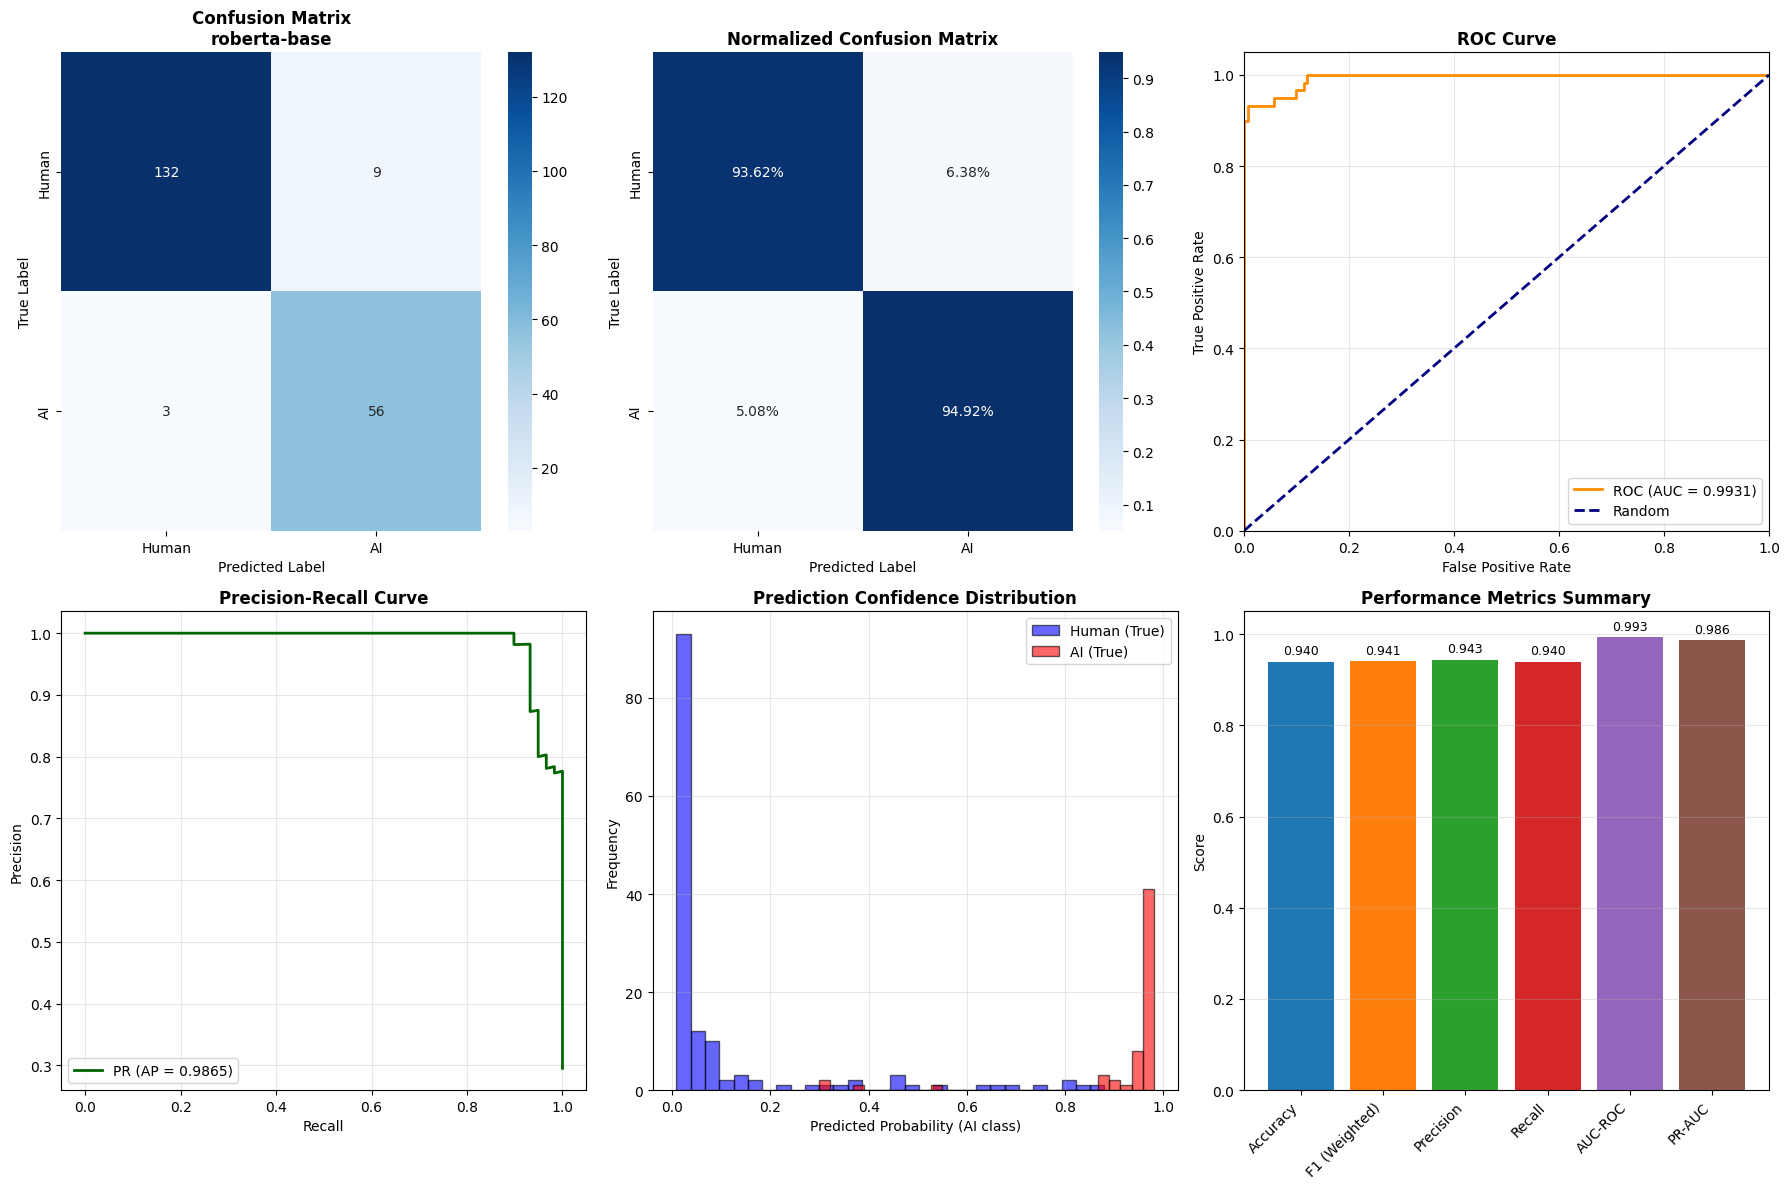

In [18]:
fig = plt.figure(figsize=(18, 12))

# 1. Confusion Matrix
ax1 = plt.subplot(2, 3, 1)
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Human', 'AI'], yticklabels=['Human', 'AI'])
plt.title(f'Confusion Matrix\n{config.MODEL_NAME}', fontsize=12, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

# 2. Normalized Confusion Matrix
ax2 = plt.subplot(2, 3, 2)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=['Human', 'AI'], yticklabels=['Human', 'AI'])
plt.title('Normalized Confusion Matrix', fontsize=12, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

# 3. ROC Curve
ax3 = plt.subplot(2, 3, 3)
fpr, tpr, _ = roc_curve(y_true, y_probs)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve', fontsize=12, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

# 4. Precision-Recall Curve
ax4 = plt.subplot(2, 3, 4)
precision_vals, recall_vals, _ = precision_recall_curve(y_true, y_probs)
avg_precision = average_precision_score(y_true, y_probs)
plt.plot(recall_vals, precision_vals, color='darkgreen', lw=2, 
         label=f'PR (AP = {avg_precision:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve', fontsize=12, fontweight='bold')
plt.legend(loc="lower left")
plt.grid(alpha=0.3)

# 5. Prediction Confidence Distribution
ax5 = plt.subplot(2, 3, 5)
human_probs = y_probs[y_true == 0]
ai_probs = y_probs[y_true == 1]
plt.hist(human_probs, bins=30, alpha=0.6, label='Human (True)', color='blue', edgecolor='black')
plt.hist(ai_probs, bins=30, alpha=0.6, label='AI (True)', color='red', edgecolor='black')
plt.xlabel('Predicted Probability (AI class)')
plt.ylabel('Frequency')
plt.title('Prediction Confidence Distribution', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

# 6. Metrics Comparison Bar Chart
ax6 = plt.subplot(2, 3, 6)
metrics_dict = {
    'Accuracy': test_results['eval_accuracy'],
    'F1 (Weighted)': test_results['eval_f1_weighted'],
    'Precision': test_results['eval_precision'],
    'Recall': test_results['eval_recall'],
    'AUC-ROC': test_results['eval_auc_roc'],
    'PR-AUC': test_results['eval_pr_auc']
}
bars = plt.bar(range(len(metrics_dict)), list(metrics_dict.values()), 
               color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b'])
plt.xticks(range(len(metrics_dict)), list(metrics_dict.keys()), rotation=45, ha='right')
plt.ylabel('Score')
plt.title('Performance Metrics Summary', fontsize=12, fontweight='bold')
plt.ylim([0, 1.05])
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (bar, value) in enumerate(zip(bars, metrics_dict.values())):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{value:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('model_evaluation_results.png', dpi=300, bbox_inches='tight')
plt.show()

In [19]:
print("\n📋 Classification Report:")
print(classification_report(y_true, y_pred, target_names=['Human', 'AI'], digits=4))



📋 Classification Report:
              precision    recall  f1-score   support

       Human     0.9778    0.9362    0.9565       141
          AI     0.8615    0.9492    0.9032        59

    accuracy                         0.9400       200
   macro avg     0.9197    0.9427    0.9299       200
weighted avg     0.9435    0.9400    0.9408       200



In [20]:
print("\n🔍 Error Analysis:")
errors = []
for i, (true, pred, prob) in enumerate(zip(y_true, y_pred, y_probs)):
    if true != pred:
        errors.append({
            'index': i,
            'true_label': 'AI' if true == 1 else 'Human',
            'pred_label': 'AI' if pred == 1 else 'Human',
            'confidence': prob if pred == 1 else 1 - prob,
            'text': test_ds[i]['text']
        })

print(f"Total errors: {len(errors)} out of {len(y_true)} ({len(errors)/len(y_true)*100:.2f}%)")

# Show sample errors
if errors:
    print("\n❌ Sample misclassifications (first 3):")
    for err in errors[:3]:
        print(f"\n  True: {err['true_label']} | Predicted: {err['pred_label']} | Confidence: {err['confidence']:.3f}")
        print(f"  Text: {err['text'][:200]}...")

# ============================================================================
# SECTION 13: COMPARISON METRICS TABLE
# ============================================================================

# Create comprehensive results table for comparison with other models
results_table = pd.DataFrame({
    'Model': [config.MODEL_NAME],
    'Accuracy': [test_results['eval_accuracy']],
    'F1 (Weighted)': [test_results['eval_f1_weighted']],
    'F1 (Human)': [test_results['eval_f1_human']],
    'F1 (AI)': [test_results['eval_f1_ai']],
    'Precision': [test_results['eval_precision']],
    'Recall': [test_results['eval_recall']],
    'AUC-ROC': [test_results['eval_auc_roc']],
    'PR-AUC': [test_results['eval_pr_auc']],
    'Train Time (s)': [train_result.metrics['train_runtime']],
    'Samples/sec': [train_result.metrics['train_samples_per_second']],
    'Test Size': [len(test_ds)]
})

print("\n📊 Results Summary Table:")
print(results_table.to_string(index=False))

# Save results to CSV for comparison
results_table.to_csv('model_comparison_results.csv', index=False)
print("\n💾 Results saved to 'model_comparison_results.csv'")



🔍 Error Analysis:
Total errors: 12 out of 200 (6.00%)

❌ Sample misclassifications (first 3):

  True: Human | Predicted: AI | Confidence: 0.702
  Text: the electoral college is a method of voting for president and vice president that was produced by our founding fathers in the articles of the constitution the electoral college has been in use for cen...

  True: AI | Predicted: Human | Confidence: 0.627
  Text: drivers should not be able to use cell phones in any capacity while operating a vehicle like i mean seriously its super dangerous anp stuff you have to have your eyes on the road anp your hands on the...

  True: Human | Predicted: AI | Confidence: 0.538
  Text: are state senatori truly have no opinion on the electoral college and whether to keep it but as this topic insists i must write my own opinion to you and here is what i think even with this article so...

📊 Results Summary Table:
       Model  Accuracy  F1 (Weighted)  F1 (Human)  F1 (AI)  Precision  Recall  AUC-ROC   P

In [21]:
# Save comprehensive results to JSON
detailed_results = {
    'model_name': config.MODEL_NAME,
    'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'config': {
        'max_length': config.MAX_LENGTH,
        'batch_size': config.BATCH_SIZE,
        'learning_rate': config.LEARNING_RATE,
        'num_epochs': config.NUM_EPOCHS,
        'weight_decay': config.WEIGHT_DECAY
    },
    'dataset_info': {
        'train_size': len(train_ds),
        'val_size': len(val_ds),
        'test_size': len(test_ds)
    },
    'metrics': {
        'accuracy': float(test_results['eval_accuracy']),
        'f1_weighted': float(test_results['eval_f1_weighted']),
        'f1_human': float(test_results['eval_f1_human']),
        'f1_ai': float(test_results['eval_f1_ai']),
        'precision': float(test_results['eval_precision']),
        'recall': float(test_results['eval_recall']),
        'auc_roc': float(test_results['eval_auc_roc']),
        'pr_auc': float(test_results['eval_pr_auc'])
    },
    'training_info': {
        'runtime_seconds': float(train_result.metrics['train_runtime']),
        'samples_per_second': float(train_result.metrics['train_samples_per_second'])
    },
    'confusion_matrix': cm.tolist(),
    'error_count': len(errors)
}

with open(config.RESULTS_FILE, 'w') as f:
    json.dump(detailed_results, f, indent=2)

print(f"💾 Detailed results saved to '{config.RESULTS_FILE}'")


💾 Detailed results saved to 'evaluation_results.json'


In [22]:
def predict(text, return_confidence=False):
    """
    Predict if text is AI-generated or Human-written
    
    Args:
        text: Input text string
        return_confidence: If True, returns (label, confidence) tuple
    
    Returns:
        Label string or (label, confidence) tuple
    """
    model.to(device)
    inputs = tokenizer(
        text, 
        return_tensors="pt", 
        truncation=True, 
        max_length=config.MAX_LENGTH
    ).to(device)
    
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1)
        pred = torch.argmax(probs, dim=-1).item()
        confidence = probs[0, pred].item()
    
    label = "AI-generated" if pred == 1 else "Human-written"
    
    if return_confidence:
        return label, confidence
    return label

In [23]:
print("\n💬 Testing inference on custom examples:")
test_examples = [
    "Artificial intelligence has revolutionized modern computing with advanced algorithms.",
    "I spent my weekend hiking in the mountains with friends and it was amazing!",
    "The implementation of neural networks requires careful consideration of hyperparameters.",
    "Yesterday I made the best pasta ever. The secret is lots of garlic and fresh basil."
]

for text in test_examples:
    label, conf = predict(text, return_confidence=True)
    print(f"\nText: '{text[:80]}...'")
    print(f"Prediction: {label} (confidence: {conf:.3f})")



💬 Testing inference on custom examples:

Text: 'Artificial intelligence has revolutionized modern computing with advanced algori...'
Prediction: AI-generated (confidence: 0.772)

Text: 'I spent my weekend hiking in the mountains with friends and it was amazing!...'
Prediction: AI-generated (confidence: 0.767)

Text: 'The implementation of neural networks requires careful consideration of hyperpar...'
Prediction: AI-generated (confidence: 0.629)

Text: 'Yesterday I made the best pasta ever. The secret is lots of garlic and fresh bas...'
Prediction: AI-generated (confidence: 0.576)


In [24]:
print(f"\n💾 Saving model to '{config.MODEL_SAVE_DIR}'...")
trainer.save_model(config.MODEL_SAVE_DIR)
tokenizer.save_pretrained(config.MODEL_SAVE_DIR)
print("✅ Model saved successfully!")

print("\n" + "="*80)
print("🎉 All done! Model training, evaluation, and analysis complete.")
print("="*80)


💾 Saving model to './roberta-base_ai_detector'...
✅ Model saved successfully!

🎉 All done! Model training, evaluation, and analysis complete.
